<a href="https://colab.research.google.com/github/erinijapranckeviciene/MF54609_18981_1_20241/blob/main/transport_loads_forecasting_AGeron_Ch13_and_Gemini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ridership time series**

In [1]:
import pandas as pd
from pathlib import Path

# data can't be accesses from the CTA website, from Kaggle -Yes.
# https://www.kaggle.com/datasets/xavierfonseca/chicago-cta-ridership-daily-boarding-totals

path = Path("sample_data/CTA_-_Ridership_-_Daily_Boarding_Totals_20240417.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]  # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)  # no need for total, it's just bus + rail
df = df.drop_duplicates()  # remove duplicated months (2011-10 and 2014-07)

In [2]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


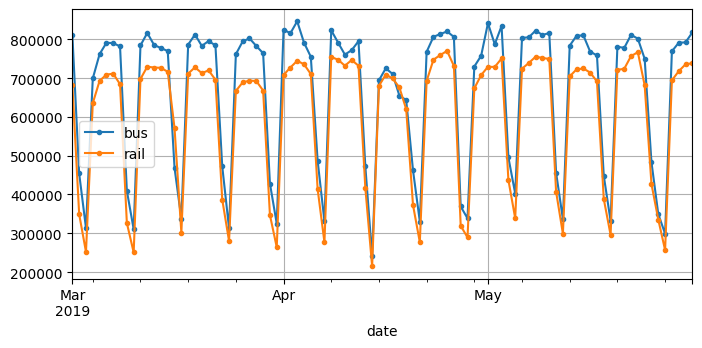

In [3]:
import matplotlib.pyplot as plt

df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8, 3.5))
plt.show()

This plots the data from the 1st of March all the way up to the 31st of May. This is a time series: data with values at different time steps, usually at regular intervals. More specifically, since there are multiple values per time step, this is called a multivariate time series. If we only looked at the bus column, it would be a univariate time series, with a single value per time step.

We can see that a similar pattern is clearly repeated every week. This is called a weekly seasonality. In fact, it’s so strong in this case that forecasting tomorrow’s ridership by just copying the values from a week earlier will yield reasonably good results. This is called naive forecasting: simply copying a past value to make our forecast. Naive forecasting is often a great baseline, and it can even be tricky to beat in some cases.

To visualize these naive forecasts, let’s overlay the two time series (for bus and rail) as well as the same time series lagged by one week (i.e., shifted toward the right) using dotted lines. We’ll also plot the difference between the two (i.e., the value at time t minus the value at time t – 7); this is called differencing

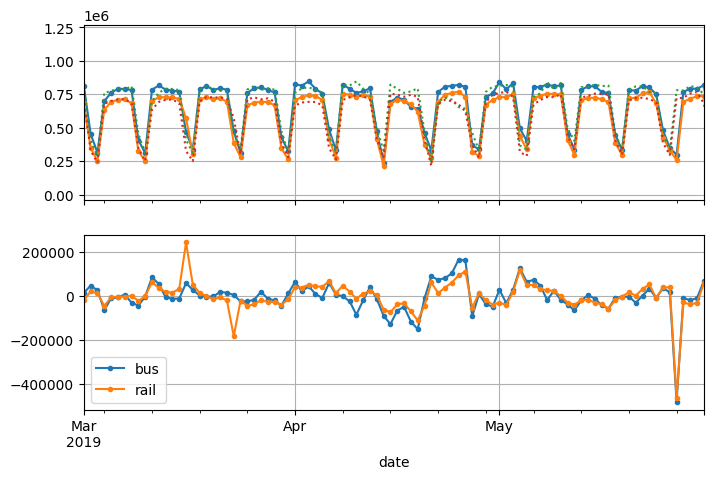

In [4]:
diff_7 = df[["bus", "rail"]].diff(7)["2019-03":"2019-05"]

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
df.plot(ax=axs[0], legend=False, marker=".")  # original time series
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":")  # lagged
diff_7.plot(ax=axs[1], grid=True, marker=".")  # 7-day difference time series
plt.show()

In [5]:
list(df.loc["2019-05-25":"2019-05-27"]["day_type"])

['A', 'U', 'U']

For now let’s just measure the mean absolute error over the three-month period we’re arbitrarily focusing on—March, April, and May 2019—to get a rough idea

In [6]:
diff_7.abs().mean()

,0
bus,43915.608696
rail,42143.271739


Our naive forecasts get a mean absolute error (MAE) of about 43,916 bus riders, and about 42,143 rail riders. It’s hard to tell at a glance how good or bad this is, so let’s put the forecast errors into perspective by dividing them by the target values

In [7]:
targets = df[["bus", "rail"]]["2019-03":"2019-05"]
(diff_7 / targets).abs().mean()

,0
bus,0.082938
rail,0.089948


What we just computed is called the mean absolute percentage error (MAPE). It looks like our naive forecasts give us a MAPE of roughly 8.3% for bus and 9.0% for rail. It’s interesting to note that the MAE for the rail forecasts looks slightly better than the MAE for the bus forecasts, while the opposite is true for the MAPE. That’s because the bus ridership is larger than the rail ridership, so naturally the forecast errors are also larger, but when we put the errors into perspective, it turns out that the bus forecasts are actually slightly better than the rail forecasts.

Looking at the time series, there doesn’t appear to be any significant monthly seasonality, but let’s check whether there’s any yearly seasonality. We’ll look at the data from 2001 to 2019. To reduce the risk of data snooping, we’ll ignore more recent data for now. Let’s also plot a 12-month rolling average for each series to visualize long-term trends

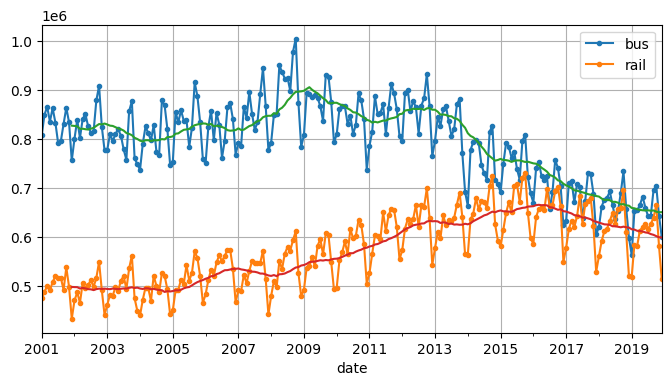

In [10]:
period = slice("2001", "2019")
df_monthly = df.select_dtypes(include="number").resample('ME').mean()
rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(8, 4))
df_monthly[period].plot(ax=ax, marker=".")
rolling_average_12_months.plot(ax=ax, grid=True, legend=False)
plt.show()

There’s definitely some yearly seasonality as well, although it is noisier than the weekly seasonality, and more visible for the rail series than the bus series: we see peaks and troughs at roughly the same dates each year. Let’s check what we get if we plot the 12-month difference

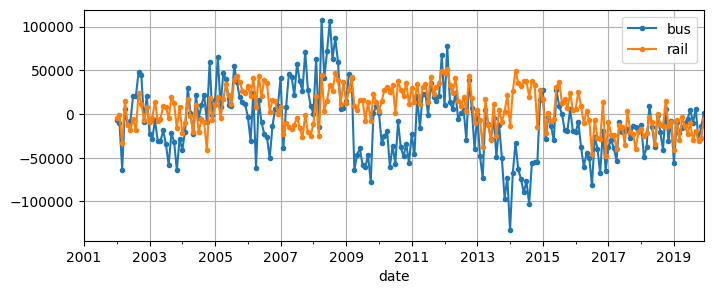

In [11]:
df_monthly.diff(12)[period].plot(grid=True, marker=".", figsize=(8, 3))
plt.show()

Notice how differencing not only removed the yearly seasonality, but it also removed the long-term trends. For example, the linear downward trend present in the time series from 2016 to 2019 became a roughly constant negative value in the differenced time series. In fact, differencing is a common technique used to remove trend and seasonality from a time series: it’s easier to study a stationary time series, meaning one whose statistical properties remain the same over time, without any seasonality or trends. Once you’re able to make accurate forecasts on the differenced time series, it’s easy to turn them into forecasts for the actual time series by just adding back the past values that were previously subtracted.

You may be thinking that we’re only trying to predict tomorrow’s ridership, so the long-term patterns matter much less than the short-term ones. You’re right, but still, we may be able to improve performance slightly by taking long-term patterns into account. For example, daily bus ridership dropped by about 2,500 in October 2017, which represents about 570 fewer passengers each week, so if we were at the end of October 2017, it would make sense to forecast tomorrow’s ridership by copying the value from last week, minus 570. Accounting for the trend will make your forecasts a bit more accurate on average.

# **Autoregressive moving average ARMA model**

The model was developed by Herman Wold in the 1930s: it computes its forecasts using a simple weighted sum of lagged values and corrects these forecasts by adding a moving average.

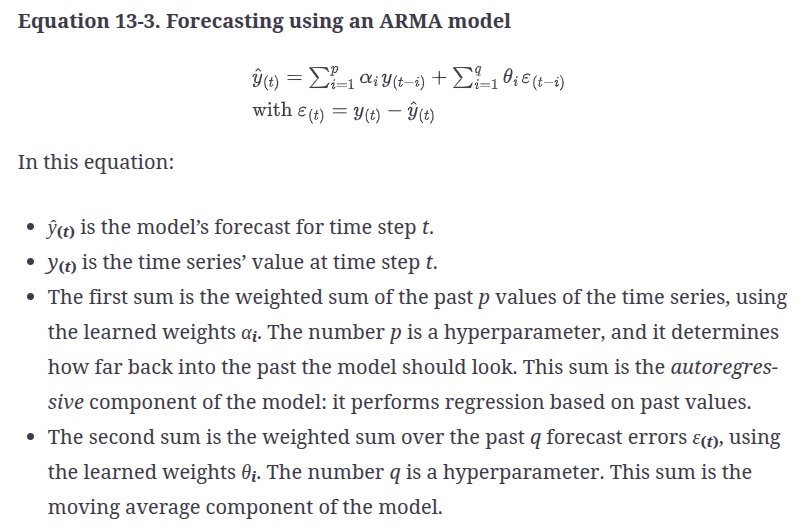

One last member of the ARMA family is the seasonal ARIMA (SARIMA) model: it models the time series in the same way as ARIMA, but it additionally models a seasonal component for a given frequency (e.g., weekly), using the exact same ARIMA approach. It has a total of seven hyperparameters: the same p, d, and q hyperparameters as ARIMA; plus additional P, D, and Q hyperparameters to model the seasonal pattern; and lastly the period of the seasonal pattern, denoted s. The hyperparameters P, D, and Q are just like p, d, and q, but they are used to model the time series at t – s, t – 2s, t – 3s, etc.

In [13]:
from statsmodels.tsa.arima.model import ARIMA

origin, today = "2019-01-01", "2019-05-31"
rail_series = df.loc[origin:today]["rail"].asfreq("D")
model = ARIMA(rail_series,
              order=(1, 0, 0),
              seasonal_order=(0, 1, 1, 7))
model = model.fit()
y_pred = model.forecast()  # returns 427,758.6

In this code example:

We start by importing the ARIMA class, then we take the rail ridership data from the start of 2019 up to “today”, and we use asfreq("D") to set the time series’ frequency to daily. This doesn’t change the data at all in this case, since it’s already daily, but without this the ARIMA class would have to guess the frequency, and it would display a warning.

Next, we create an ARIMA instance, passing it all the data until “today”, and we set the model hyperparameters: order=(1, 0, 0) means that p = 1, d = 0, and q = 0; and seasonal_order=(0, 1, 1, 7) means that P = 0, D = 1, Q = 1, and s = 7. Notice that the statsmodels API differs a bit from Scikit-Learn’s API, since we pass the data to the model at construction time, instead of passing it to the fit() method.

Next, we fit the model, and we use it to make a forecast for “tomorrow”, the 1st of June, 2019.

The forecast is 427,759 passengers, when in fact there were 379,044. Yikes, we’re 12.9% off—that’s pretty bad. It’s actually slightly worse than naive forecasting.

In [17]:
origin, start_date, end_date = "2019-01-01", "2019-03-01", "2019-05-31"
time_period = pd.date_range(start_date, end_date)
rail_series = df.loc[origin:end_date]["rail"].asfreq("D")
y_preds = []
for today in time_period.shift(-1):
    model = ARIMA(rail_series[origin:today],  # train on data up to "today"
                  order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, 7))
    model = model.fit()  # note that we retrain the model every day!
    y_pred = model.forecast().iloc[0]
    y_preds.append(y_pred)

y_preds = pd.Series(y_preds, index=time_period)
mae = (y_preds - rail_series[time_period]).abs().mean()  # returns 32,040.7

In [15]:
mae

np.float64(32040.720094289627)

<Axes: >

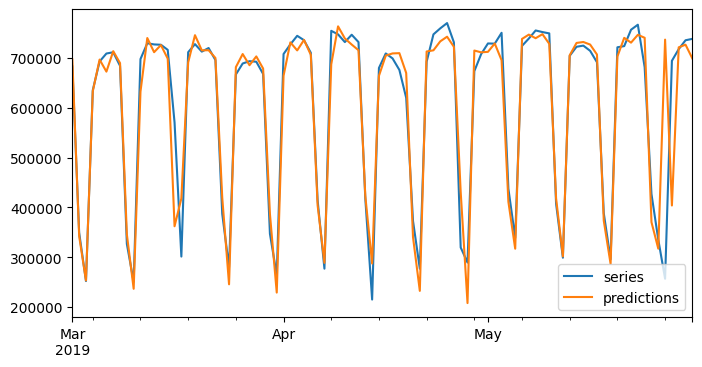

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
dfplot=pd.DataFrame({'series': rail_series[time_period], 'predictions':y_preds})
dfplot.plot(ax=ax)

# **Preparing data for neural networks**

Our goal will be to forecast tomorrow’s ridership based on the ridership of the past 8 weeks of data (56 days). The inputs to our model will therefore be sequences (usually a single sequence per day once the model is in production), each containing 56 values from time steps t – 55 to t. For each input sequence, the model will output a single value: the forecast for time step t + 1.

But what will we use as training data? Well, here’s the trick: we will use every 56-day window from the past as training data, and the target for each window will be the value immediately following it. To do that, we need to create a custom dataset that will chop a given time series into all possible windows of a given length, each with its corresponding target.

Here’s an
example that takes a time series containing the numbers 0 to 5 and creates a dataset
containing all the windows of length 3, with their corresponding targets, grouped
into batches of size 2:

In [18]:
import tensorflow as tf
my_series = [0, 1, 2, 3, 4, 5]
my_dataset = tf.keras.utils.timeseries_dataset_from_array(
  my_series,
  targets=my_series[3:], # the targets are 3 steps into the future
  sequence_length=3,
  batch_size=2
)

In [19]:
list(my_dataset)

[(<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[0, 1, 2],
         [1, 2, 3]], dtype=int32)>,
  <tf.Tensor: shape=(2,), dtype=int32, numpy=array([3, 4], dtype=int32)>),
 (<tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[2, 3, 4]], dtype=int32)>,
  <tf.Tensor: shape=(1,), dtype=int32, numpy=array([5], dtype=int32)>)]

Each sample in the dataset is a window of length 3, along with its corresponding
target (i.e., the value immediately after the window). The windows are [0, 1, 2], [1,
2, 3], and [2, 3, 4], and their respective targets are 3, 4, and 5. Since there are three
windows in total, which is not a multiple of the batch size, the last batch only contains
one window instead of two.

Another way to get the same result is to use the window() method of tf.data’s Dataset
class. It’s more complex, but it gives you full control. The window() method returns a dataset of
window datasets

In [20]:
for window_dataset in tf.data.Dataset.range(6).window(4, shift=1):
  for element in window_dataset:
    print(f"{element}", end=" ")
  print()

0 1 2 3 
1 2 3 4 
2 3 4 5 
3 4 5 
4 5 
5 


In this example, the dataset contains six windows, each shifted by one step compared
to the previous one, and the last three windows are smaller because they’ve reached
the end of the series.

In general you’ll want to get rid of these smaller windows by
passing drop_remainder=True to the window() method.


The window() method returns a nested dataset, analogous to a list of lists. This is
useful when you want to transform each window by calling its dataset methods (e.g.,
to shuffle them or batch them). However, we cannot use a nested dataset directly for
training, as our model will expect tensors as input, not datasets.


Therefore, we must call the flat_map() method: it converts a nested dataset into a
flat dataset (one that contains tensors, not datasets). For example, suppose {1, 2, 3}
represents a dataset containing the sequence of tensors 1, 2, and 3. If you flatten the
nested dataset {{1, 2}, {3, 4, 5, 6}}, you get back the flat dataset {1, 2, 3, 4, 5, 6}.


Moreover, the flat_map() method takes a function as an argument, which allows you
to transform each dataset in the nested dataset before flattening. For example, if you
pass the function lambda ds: ds.batch(2) to flat_map(), then it will transform the
nested dataset {{1, 2}, {3, 4, 5, 6}} into the flat dataset {[1, 2], [3, 4], [5, 6]}: it’s a dataset
containing 3 tensors, each of size 2.

In [21]:
dataset = tf.data.Dataset.range(6).window(4, shift=1, drop_remainder=True)
dataset = dataset.flat_map(lambda window_dataset: window_dataset.batch(4))
for window_tensor in dataset:
  print(f"{window_tensor}")

[0 1 2 3]
[1 2 3 4]
[2 3 4 5]


In [22]:
def to_windows(dataset, length):
  dataset = dataset.window(length, shift=1, drop_remainder=True)
  return dataset.flat_map(lambda window_ds: window_ds.batch(length))

In [23]:
dataset = to_windows(tf.data.Dataset.range(6), 4) # 3 inputs + 1 target = 4
dataset = dataset.map(lambda window: (window[:-1], window[-1]))
list(dataset.batch(2))

[(<tf.Tensor: shape=(2, 3), dtype=int64, numpy=
  array([[0, 1, 2],
         [1, 2, 3]])>,
  <tf.Tensor: shape=(2,), dtype=int64, numpy=array([3, 4])>),
 (<tf.Tensor: shape=(1, 3), dtype=int64, numpy=array([[2, 3, 4]])>,
  <tf.Tensor: shape=(1,), dtype=int64, numpy=array([5])>)]

As you can see, we now have the same output as we got earlier with the
timeseries_dataset_from_array() function.

Now, before we start training, we need to split our data into a training period, a
validation period, and a test period. We will focus on the rail ridership for now. We
will also scale it down by a factor of one million, to ensure the values are near the 0–1
range; this plays nicely with the default weight initialization and learning rate:

In [25]:
rail_train = df["rail"]["2016-01":"2018-12"] / 1e6
rail_valid = df["rail"]["2019-01":"2019-05"] / 1e6
rail_test = df["rail"]["2019-06":] / 1e6

Next, let’s use timeseries_dataset_from_array() to create datasets for training and
validation. Since gradient descent expects the instances in the training set to be
independent and identically distributed (IID), we must set the
argument shuffle=True to shuffle the training windows (but not their contents)

In [26]:
seq_length = 56
train_ds = tf.keras.utils.timeseries_dataset_from_array(
rail_train.to_numpy(),
targets=rail_train[seq_length:],
sequence_length=seq_length,
batch_size=32,
shuffle=True,
seed=42
)
valid_ds = tf.keras.utils.timeseries_dataset_from_array(
rail_valid.to_numpy(),
targets=rail_valid[seq_length:],
sequence_length=seq_length,
batch_size=32
)

And now we’re ready to build and train any regression model we want!

# **Forecasting using a linear model**

Let’s try a basic linear model first. We will use the Huber loss, which usually works
better than minimizing the MAE directly. We’ll also use
early stopping.

**Model training API**
https://keras.io/api/models/model_training_apis/

In [28]:
tf.random.set_seed(42)
model = tf.keras.Sequential([tf.keras.layers.Dense(1, input_shape=[seq_length])])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=50, restore_best_weights=True)

opt = tf.keras.optimizers.SGD(learning_rate=0.02, momentum=0.9)

model.compile(loss=tf.keras.losses.Huber(), optimizer=opt, metrics=["mae"])

history = model.fit(train_ds, validation_data=valid_ds, epochs=500, callbacks=[early_stopping_cb])

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1865 - mae: 0.5060 - val_loss: 0.0092 - val_mae: 0.0932
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0190 - mae: 0.1462 - val_loss: 0.0072 - val_mae: 0.0826
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0084 - mae: 0.0893 - val_loss: 0.0064 - val_mae: 0.0776
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0085 - mae: 0.0904 - val_loss: 0.0059 - val_mae: 0.0747
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0071 - mae: 0.0803 - val_loss: 0.0059 - val_mae: 0.0761
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0072 - mae: 0.0808 - val_loss: 0.0054 - val_mae: 0.0723
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0057 - mae: 0.0733 - val_loss: 0.0049 - val_mae: 0.0678
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0061 - mae: 0.0731 - val_loss: 0.0046 - val_mae: 0.0648
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0

# **The following was generated with Gemini**

In [29]:
import os

# Create the test dataset similar to train_ds and valid_ds
# We use the full `rail_test` series for targets as we're forecasting each step after a sequence.
test_ds = tf.keras.utils.timeseries_dataset_from_array(
    rail_test.to_numpy(),
    targets=rail_test[seq_length:],
    sequence_length=seq_length,
    batch_size=32
)

# Define ModelCheckpoint callback to save the best model
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath="best_model.keras", # Name of the file to save the model
    save_best_only=True,         # Only save when validation metrics improve
    monitor="val_mae",           # Monitor validation MAE
    mode="min",                  # We want to minimize MAE
    verbose=1
)

# Re-run model training with ModelCheckpoint
tf.random.set_seed(42)
model = tf.keras.Sequential([tf.keras.layers.Dense(1, input_shape=[seq_length])])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=50, restore_best_weights=True)

opt = tf.keras.optimizers.SGD(learning_rate=0.02, momentum=0.9)

model.compile(loss=tf.keras.losses.Huber(), optimizer=opt, metrics=["mae"])

# Include the ModelCheckpoint callback in the fit method
history = model.fit(train_ds, validation_data=valid_ds, epochs=500, callbacks=[early_stopping_cb, checkpoint_cb])

# Now, load the best model saved by ModelCheckpoint
loaded_model = tf.keras.models.load_model("best_model.keras")

# Evaluate the loaded model on the test dataset
test_loss, test_mae = loaded_model.evaluate(test_ds)

print(f"Test MAE: {test_mae*1e6:.2f}") # Multiply by 1e6 to get original scale
print(f"Test Loss: {test_loss:.4f}")

Epoch 1/500


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


24/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1520 - mae: 0.4668
Epoch 1: val_mae improved from inf to 0.12870, saving model to best_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1346 - mae: 0.4316 - val_loss: 0.0125 - val_mae: 0.1287
Epoch 2/500
21/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0132 - mae: 0.1239
Epoch 2: val_mae improved from 0.12870 to 0.08585, saving model to best_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0126 - mae: 0.1201 - val_loss: 0.0057 - val_mae: 0.0859
Epoch 3/500
27/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0076 - mae: 0.0898
Epoch 3: val_mae improved from 0.08585 to 0.07935, saving model to best_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0077 - mae: 0.0902 - val_loss: 0.0056 - val_mae: 0.0793
Epoch 4/500
21/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0071 - mae: 0.0894
Epoch 4: val_mae improved from 0.07935 to 0.07582, saving model to best_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - l

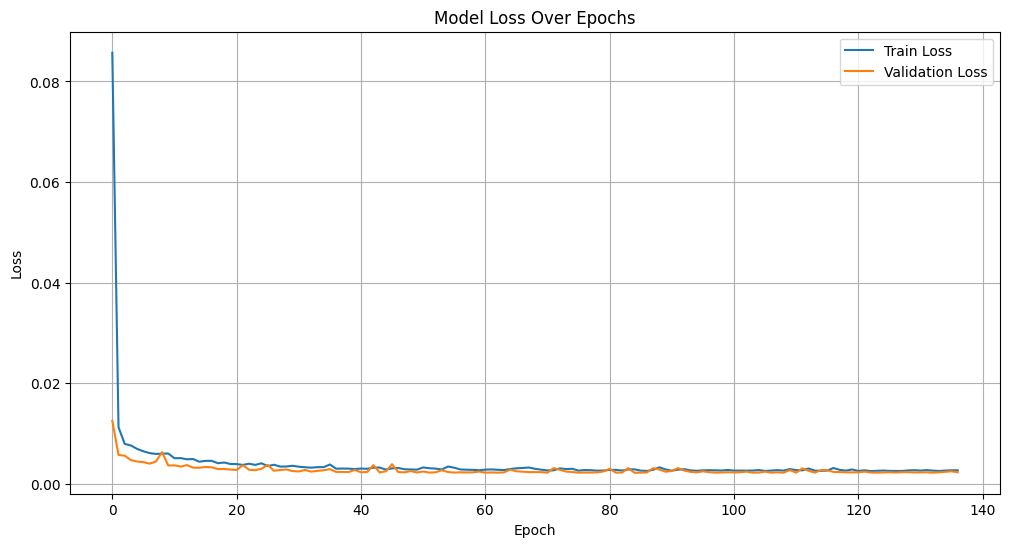

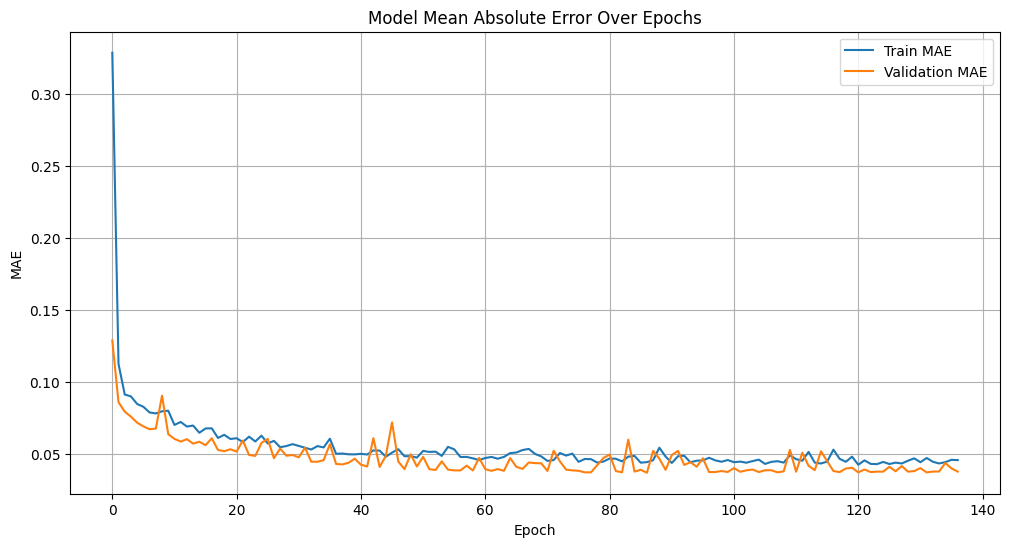

In [30]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Plot training & validation MAE values
plt.figure(figsize=(12, 6))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model Mean Absolute Error Over Epochs')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# *Recurrent network*

In [ ]:
model = tf.keras.Sequential([
tf.keras.layers.SimpleRNN(1, input_shape=[None, 1])
])

In [31]:
univar_model = tf.keras.Sequential([
tf.keras.layers.SimpleRNN(32, input_shape=[None, 1]),
tf.keras.layers.Dense(1) # no activation function by default
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
tf.random.set_seed(42)

# Define ModelCheckpoint callback to save the best model
checkpoint_cb_univar = tf.keras.callbacks.ModelCheckpoint(
    filepath="best_univar_model.keras",
    save_best_only=True,
    monitor="val_mae",
    mode="min",
    verbose=1
)

# Instantiate the univar_model (defined in F2MUo46XdwOB)
univar_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 1]),
    tf.keras.layers.Dense(1)
])

early_stopping_cb_univar = tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=50, restore_best_weights=True)

opt_univar = tf.keras.optimizers.SGD(learning_rate=0.02, momentum=0.9)

univar_model.compile(loss=tf.keras.losses.Huber(), optimizer=opt_univar, metrics=["mae"])

history_univar = univar_model.fit(train_ds, validation_data=valid_ds, epochs=500, callbacks=[early_stopping_cb_univar, checkpoint_cb_univar])

# Load the best univar model saved by ModelCheckpoint
loaded_univar_model = tf.keras.models.load_model("best_univar_model.keras")

# Evaluate the loaded model on the test dataset
test_loss_univar, test_mae_univar = loaded_univar_model.evaluate(test_ds)

print(f"Univar Model Test MAE: {test_mae_univar*1e6:.2f}")
print(f"Univar Model Test Loss: {test_loss_univar:.4f}")

Epoch 1/500
30/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1046 - mae: 0.3384
Epoch 1: val_mae improved from inf to 0.09657, saving model to best_univar_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0974 - mae: 0.3236 - val_loss: 0.0070 - val_mae: 0.0966
Epoch 2/500
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0075 - mae: 0.0993
Epoch 2: val_mae improved from 0.09657 to 0.07152, saving model to best_univar_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0075 - mae: 0.0989 - val_loss: 0.0040 - val_mae: 0.0715
Epoch 3/500
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0060 - mae: 0.0804
Epoch 3: val_mae did not improve from 0.07152
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0060 - mae: 0.0803 - val_loss: 0.0041 - val_mae: 0.0715
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0049 - mae: 0.0718
Epoch 4: val_mae improved from 0.07152 to 0.05975, saving model to best_univar_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - l

In [ ]:
# Evaluate the loaded model on the test dataset
test_loss_univar, test_mae_univar = loaded_univar_model.evaluate(test_ds)

print(f"Univar Model Test MAE: {test_mae_univar*1e6:.2f}")
print(f"Univar Model Test Loss: {test_loss_univar:.4f}")

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0179 - mae: 0.1513
Univar Model Test MAE: 172307.98
Univar Model Test Loss: 0.0191


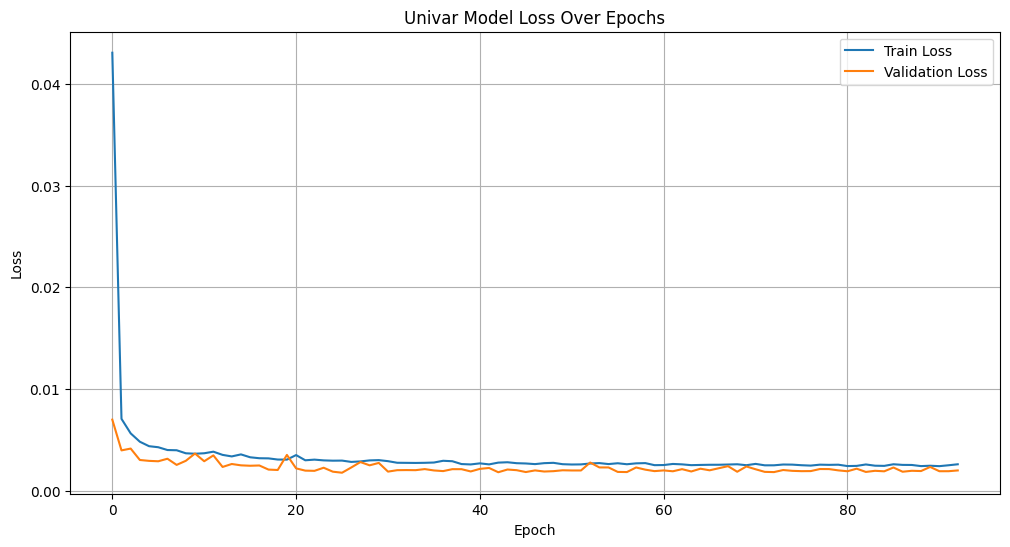

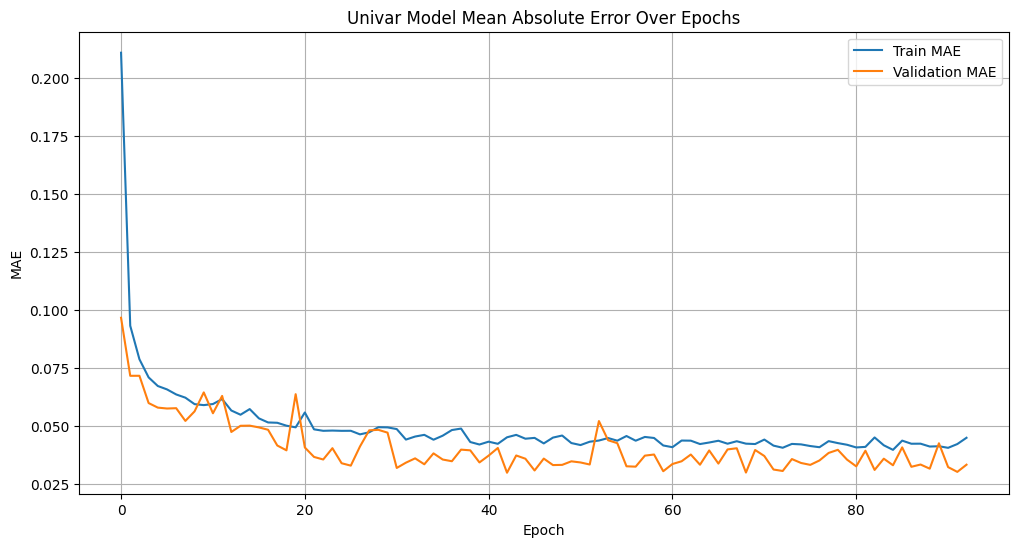

In [33]:
import matplotlib.pyplot as plt

# Plot training & validation loss values for univar_model
plt.figure(figsize=(12, 6))
plt.plot(history_univar.history['loss'], label='Train Loss')
plt.plot(history_univar.history['val_loss'], label='Validation Loss')
plt.title('Univar Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Plot training & validation MAE values for univar_model
plt.figure(figsize=(12, 6))
plt.plot(history_univar.history['mae'], label='Train MAE')
plt.plot(history_univar.history['val_mae'], label='Validation MAE')
plt.title('Univar Model Mean Absolute Error Over Epochs')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


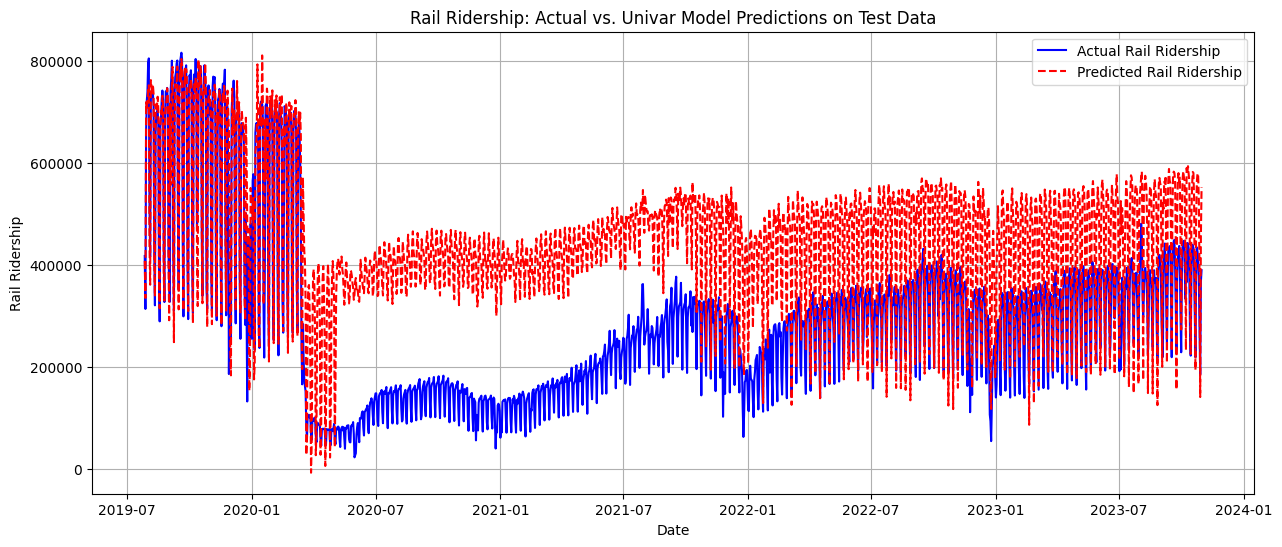

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Make predictions on the test dataset
y_pred_univar = loaded_univar_model.predict(test_ds)

# Reshape predictions and scale back to original range
y_pred_univar_scaled = y_pred_univar.flatten() * 1e6

# Get the actual target values from rail_test
# The targets for test_ds start from rail_test.index[seq_length]
actual_univar = rail_test[seq_length:] * 1e6

# Create a pandas Series for the predictions with the correct index
# Ensure the length of predictions matches the length of actual targets
predictions_series = pd.Series(y_pred_univar_scaled[:len(actual_univar)], index=actual_univar.index)

# Plotting
plt.figure(figsize=(15, 6))
plt.plot(actual_univar.index, actual_univar.values, label='Actual Rail Ridership', color='blue')
plt.plot(predictions_series.index, predictions_series.values, label='Predicted Rail Ridership', color='red', linestyle='--')
plt.title('Rail Ridership: Actual vs. Univar Model Predictions on Test Data')
plt.xlabel('Date')
plt.ylabel('Rail Ridership')
plt.legend()
plt.grid(True)
plt.show()

# Task
To create a time series forecasting model that predicts multi-step (7-day) rail ridership:

1.  **Prepare multi-step time series data**:
    -   Define a helper function `prepare_multi_step_data` to generate input sequences (X) of `sequence_length` (56 days) and corresponding 7-day target sequences (y) from the raw time series.
    -   Apply this function to `rail_train`, `rail_valid`, and `rail_test` (which are already scaled and defined in the notebook) to create `tf.data.Dataset` objects for efficient training, validation, and testing. The input sequences `X` will be reshaped to `(samples, timesteps, features)` suitable for RNN input.

2.  **Define and compile multi-step RNN model**:
    -   Construct a `tf.keras.Sequential` model.
    -   The model will consist of a `SimpleRNN` layer (with 32 units and `input_shape=[None, 1]`) to process the input sequences.
    -   A `Dense` output layer with 7 units will follow the `SimpleRNN` layer, corresponding to the 7-day prediction horizon.
    -   Compile the model using `tf.keras.losses.Huber()` as the loss function, 'mae' as a metric, and `tf.keras.optimizers.SGD` with `learning_rate=0.02` and `momentum=0.9`.

3.  **Train the model with callbacks**:
    -   Set up `tf.keras.callbacks.EarlyStopping` to monitor `val_mae` with a patience of 50 epochs, restoring the best weights.
    -   Set up `tf.keras.callbacks.ModelCheckpoint` to save the best model based on the lowest `val_mae` to `best_multi_step_model.keras`.
    -   Train the multi-step RNN model using the prepared datasets (`train_multi_ds`, `valid_multi_ds`) and these callbacks for up to 500 epochs.

4.  **Evaluate the model on test data**:
    -   Load the best performing model saved by the `ModelCheckpoint` callback.
    -   Evaluate its performance (loss and MAE) on the `test_multi_ds` dataset.
    -   Print the test MAE and loss, scaling the MAE back to the original ridership values (by multiplying by 1e6).

5.  **Visualize training history and predictions**:
    -   Plot the training and validation loss over epochs to visualize the model's learning process.
    -   Plot the training and validation MAE over epochs to track error reduction.
    -   Generate multi-step predictions on the `test_multi_ds`.
    -   Extract and plot the actual vs. predicted rail ridership for the *first day* of each 7-day prediction window on the test set, scaling the values back to their original units.

```python
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# Assume rail_train, rail_valid, rail_test are already defined and scaled as in previous cells
# For demonstration, re-defining them if this cell is run independently
if 'df' not in locals():
    # This part would typically be in previous cells, re-including for standalone execution
    from pathlib import Path
    path = Path("sample_data/CTA_-_Ridership_-_Daily_Boarding_Totals_20240417.csv")
    df = pd.read_csv(path, parse_dates=["service_date"])
    df.columns = ["date", "day_type", "bus", "rail", "total"]
    df = df.sort_values("date").set_index("date")
    df = df.drop("total", axis=1)
    df = df.drop_duplicates()
rail_train = df["rail"]["2016-01":"2018-12"] / 1e6
rail_valid = df["rail"]["2019-01":"2019-05"] / 1e6
rail_test = df["rail"]["2019-06":] / 1e6

# 1. Prepare multi-step time series data
def prepare_multi_step_data(series, sequence_length, output_steps, batch_size, shuffle=False, seed=None):
    X = []
    y = []
    
    # Loop through the series to create sequences and corresponding multi-step targets
    # The loop needs enough data for both the input sequence and the output sequence
    for i in range(len(series) - sequence_length - output_steps + 1):
        X.append(series[i : i + sequence_length])
        y.append(series[i + sequence_length : i + sequence_length + output_steps])
    
    X = np.array(X)
    y = np.array(y)
    
    # Reshape X to (samples, timesteps, features) for RNN input
    # Assuming univariate time series, so add a feature dimension of 1
    X = X.reshape(X.shape[0], X.shape[1], 1)

    # Convert to tf.data.Dataset
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X), seed=seed)
    
    dataset = dataset.batch(batch_size).prefetch(1)
    
    return dataset

# Parameters for multi-step prediction
multi_step_seq_length = 56 # Input sequence length (56 days)
multi_step_output_steps = 7 # Predict next 7 days
batch_size = 32

# Prepare multi-step data for training, validation, and testing
train_multi_ds = prepare_multi_step_data(rail_train.to_numpy(), multi_step_seq_length, multi_step_output_steps, batch_size, shuffle=True, seed=42)
valid_multi_ds = prepare_multi_step_data(rail_valid.to_numpy(), multi_step_seq_length, multi_step_output_steps, batch_size)
test_multi_ds = prepare_multi_step_data(rail_test.to_numpy(), multi_step_seq_length, multi_step_output_steps, batch_size)

# Verify the shape of a batch
print("--- Data Preparation Verification ---")
for X_batch, y_batch in train_multi_ds.take(1):
    print("X_batch shape:", X_batch.shape) # Expected: (batch_size, multi_step_seq_length, 1)
    print("y_batch shape:", y_batch.shape) # Expected: (batch_size, multi_step_output_steps)
print("-----------------------------------")

# 2. Define and compile multi-step RNN model
tf.random.set_seed(42)

multi_step_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 1]), # SimpleRNN layer with 32 units
    tf.keras.layers.Dense(multi_step_output_steps) # Dense output layer for 7-day predictions
])

opt_multi_step = tf.keras.optimizers.SGD(learning_rate=0.02, momentum=0.9)
multi_step_model.compile(loss=tf.keras.losses.Huber(), optimizer=opt_multi_step, metrics=["mae"])

# 3. Train the model with callbacks
# Callbacks
early_stopping_cb_multi_step = tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=50, restore_best_weights=True)
checkpoint_cb_multi_step = tf.keras.callbacks.ModelCheckpoint(
    filepath="best_multi_step_model.keras",
    save_best_only=True,
    monitor="val_mae",
    mode="min",
    verbose=1
)

print("\n--- Training Multi-step RNN Model ---")
history_multi_step = multi_step_model.fit(
    train_multi_ds,
    validation_data=valid_multi_ds,
    epochs=500, # Max epochs
    callbacks=[early_stopping_cb_multi_step, checkpoint_cb_multi_step]
)

# 4. Evaluate the model on test data
# Load the best multi-step model
loaded_multi_step_model = tf.keras.models.load_model("best_multi_step_model.keras")

# Evaluate on test data
print("\n--- Evaluating Multi-step RNN Model on Test Data ---")
test_loss_multi_step, test_mae_multi_step = loaded_multi_step_model.evaluate(test_multi_ds)

print(f"Multi-step Model Test MAE: {test_mae_multi_step * 1e6:.2f}") # Scale back to original range
print(f"Multi-step Model Test Loss: {test_loss_multi_step:.4f}")

# 5. Visualize training history and predictions
# Plot training history (Loss)
plt.figure(figsize=(12, 6))
plt.plot(history_multi_step.history['loss'], label='Train Loss')
plt.plot(history_multi_step.history['val_loss'], label='Validation Loss')
plt.title('Multi-step Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Plot training history (MAE)
plt.figure(figsize=(12, 6))
plt.plot(history_multi_step.history['mae'], label='Train MAE')
plt.plot(history_multi_step.history['val_mae'], label='Validation MAE')
plt.title('Multi-step Model Mean Absolute Error Over Epochs')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Generate multi-step predictions on test data
print("\n--- Generating Predictions on Test Data ---")
y_pred_multi_step = loaded_multi_step_model.predict(test_multi_ds)

# We need to extract the actual multi-step targets from test_multi_ds
actual_multi_step_targets = np.concatenate([y_batch.numpy() for _, y_batch in test_multi_ds], axis=0)

# Scale back to original range
y_pred_multi_step_scaled = y_pred_multi_step * 1e6
actual_multi_step_scaled = actual_multi_step_targets * 1e6

# For visualization, let's plot the first day of each 7-day prediction
# The index for the predictions will correspond to the start of each target sequence
# The `prepare_multi_step_data` function created X_i = series[i : i+seq_length] and y_i = series[i+seq_length : i+seq_length+output_steps]
# So, the first prediction (y_i[0]) corresponds to series[i+seq_length]
# The index of actual_multi_step_scaled[j, 0] is rail_test.index[j + multi_step_seq_length]
predicted_first_day = y_pred_multi_step_scaled[:, 0]
actual_first_day = actual_multi_step_scaled[:, 0]

# Determine the start and end dates for the plot on rail_test
plot_start_index = rail_test.index[multi_step_seq_length]
plot_end_index = rail_test.index[multi_step_seq_length + len(actual_first_day) - 1]
plot_dates = pd.date_range(start=plot_start_index, end=plot_end_index, freq='D')

plt.figure(figsize=(15, 6))
plt.plot(plot_dates, actual_first_day, label='Actual Rail Ridership (Day 1 of 7-day target)', color='blue')
plt.plot(plot_dates, predicted_first_day, label='Predicted Rail Ridership (Day 1 of 7-day target)', color='red', linestyle='--')
plt.title('Rail Ridership: Actual vs. Multi-step RNN Predictions (First Day of Target)')
plt.xlabel('Date')
plt.ylabel('Rail Ridership')
plt.legend()
plt.grid(True)
plt.show()

```

## Prepare multi-step time series data

### Subtask:
Define a helper function to create input sequences (X) and 7-day target sequences (y) from the time series. Apply this function to `rail_train`, `rail_valid`, and `rail_test` to generate the respective X and y arrays. Reshape X for RNN input (samples, timesteps, features) and convert these NumPy arrays into `tf.data.Dataset` objects for efficient training.


**Reasoning**:
I will define the `prepare_multi_step_data` function as instructed, which will create input (X) and target (y) sequences, reshape X for RNN input, and convert them into `tf.data.Dataset` objects. Then, I will apply this function to the `rail_train`, `rail_valid`, and `rail_test` Series to generate the required datasets and print the shapes of a sample batch for verification.



In [35]:
import numpy as np

def prepare_multi_step_data(series, sequence_length, output_steps, batch_size, shuffle=False, seed=None):
    X_data = []
    y_data = []
    for i in range(len(series) - sequence_length - output_steps + 1):
        X_data.append(series[i : i + sequence_length])
        y_data.append(series[i + sequence_length : i + sequence_length + output_steps])

    X_data = np.array(X_data)
    y_data = np.array(y_data)

    # Reshape X for RNN input: (samples, timesteps, features)
    X_data = X_data.reshape(X_data.shape[0], X_data.shape[1], 1)

    dataset = tf.data.Dataset.from_tensor_slices((X_data, y_data))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X_data), seed=seed)

    dataset = dataset.batch(batch_size).prefetch(1)
    return dataset

multi_step_seq_length = 56
multi_step_output_steps = 7
batch_size = 32

train_multi_ds = prepare_multi_step_data(
    rail_train.to_numpy(),
    multi_step_seq_length,
    multi_step_output_steps,
    batch_size,
    shuffle=True,
    seed=42
)

valid_multi_ds = prepare_multi_step_data(
    rail_valid.to_numpy(),
    multi_step_seq_length,
    multi_step_output_steps,
    batch_size
)

test_multi_ds = prepare_multi_step_data(
    rail_test.to_numpy(),
    multi_step_seq_length,
    multi_step_output_steps,
    batch_size
)

print("Verification of multi-step datasets:")
for X_batch, y_batch in train_multi_ds.take(1):
    print(f"X_batch shape: {X_batch.shape}")
    print(f"y_batch shape: {y_batch.shape}")

Verification of multi-step datasets:
X_batch shape: (32, 56, 1)
y_batch shape: (32, 7)


**Reasoning**:
I will define and compile the multi-step RNN model as per the instructions, specifying a `SimpleRNN` layer followed by a `Dense` output layer with 7 units for multi-step predictions. The model will be compiled with the Huber loss, MAE metric, and SGD optimizer with the specified learning rate and momentum.



In [37]:
tf.random.set_seed(42)

multi_step_model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32, input_shape=[None, 1]), # SimpleRNN layer with 32 units
    tf.keras.layers.Dense(multi_step_output_steps) # Dense output layer for 7-day predictions
])

opt_multi_step = tf.keras.optimizers.SGD(learning_rate=0.02, momentum=0.9)
multi_step_model.compile(loss=tf.keras.losses.Huber(), optimizer=opt_multi_step, metrics=["mae"])

print("Multi-step RNN model defined and compiled.")

Multi-step RNN model defined and compiled.


**Reasoning**:
I will now train the multi-step RNN model using the prepared datasets and the specified callbacks (`EarlyStopping` and `ModelCheckpoint`) to monitor and save the best model.



In [39]:
early_stopping_cb_multi_step = tf.keras.callbacks.EarlyStopping(monitor="val_mae", patience=50, restore_best_weights=True)
checkpoint_cb_multi_step = tf.keras.callbacks.ModelCheckpoint(
    filepath="best_multi_step_model.keras",
    save_best_only=True,
    monitor="val_mae",
    mode="min",
    verbose=1
)

print("--- Training Multi-step RNN Model ---")
history_multi_step = multi_step_model.fit(
    train_multi_ds,
    validation_data=valid_multi_ds,
    epochs=500,
    callbacks=[early_stopping_cb_multi_step, checkpoint_cb_multi_step]
)

print("Multi-step RNN model training complete.")

--- Training Multi-step RNN Model ---
Epoch 1/500
31/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0034 - mae: 0.0476
Epoch 1: val_mae improved from inf to 0.03636, saving model to best_multi_step_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0033 - mae: 0.0475 - val_loss: 0.0017 - val_mae: 0.0364
Epoch 2/500
29/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0029 - mae: 0.0447
Epoch 2: val_mae improved from 0.03636 to 0.03386, saving model to best_multi_step_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0030 - mae: 0.0449 - val_loss: 0.0016 - val_mae: 0.0339
Epoch 3/500
29/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0031 - mae: 0.0461
Epoch 3: val_mae did not improve from 0.03386
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0031 - mae: 0.0461 - val_loss: 0.0016 - val_mae: 0.0340
Epoch 4/500
30/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0031 - mae: 0.0468
Epoch 4: val_mae did not improve from 0.03386
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - 

**Reasoning**:
I will evaluate the loaded best multi-step model on the test data to get the test loss and MAE. The MAE will be scaled back to the original ridership values for better interpretability.



In [41]:
print("\n--- Evaluating Multi-step RNN Model on Test Data ---")
loaded_multi_step_model = tf.keras.models.load_model("best_multi_step_model.keras")
test_loss_multi_step, test_mae_multi_step = loaded_multi_step_model.evaluate(test_multi_ds)

print(f"Multi-step Model Test MAE: {test_mae_multi_step * 1e6:.2f}") # Scale back to original range
print(f"Multi-step Model Test Loss: {test_loss_multi_step:.4f}")


--- Evaluating Multi-step RNN Model on Test Data ---
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0196 - mae: 0.1530
Multi-step Model Test MAE: 177125.51
Multi-step Model Test Loss: 0.0216


**Reasoning**:
I will now visualize the training history (loss and MAE) and plot the actual vs. predicted rail ridership for the first day of each 7-day prediction window on the test set, as requested by the final part of the subtask.



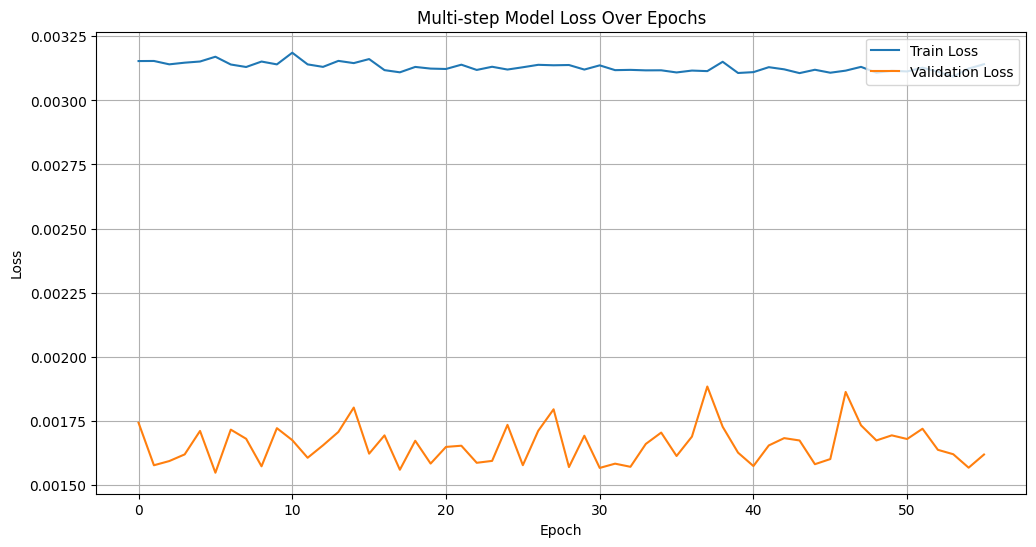

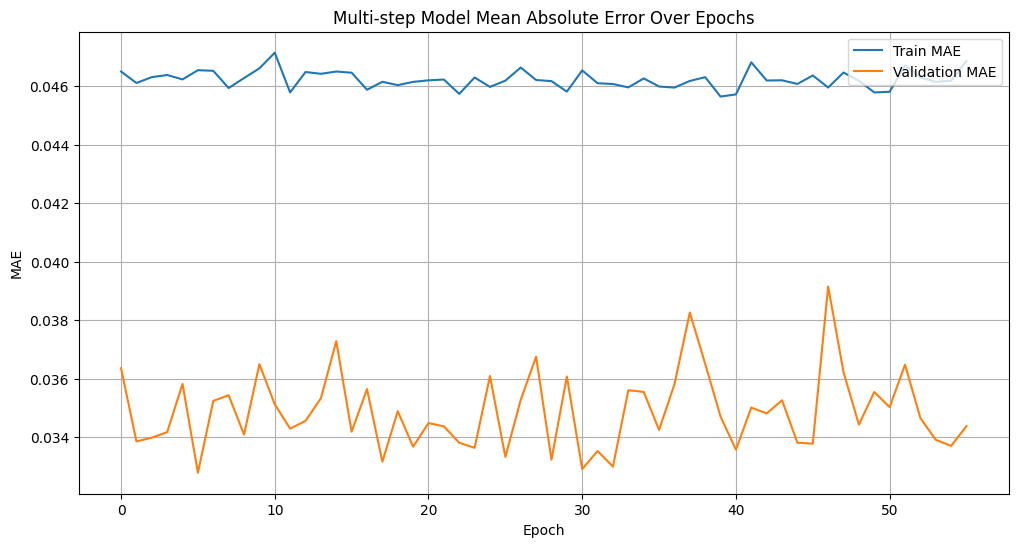


--- Generating Predictions on Test Data ---
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


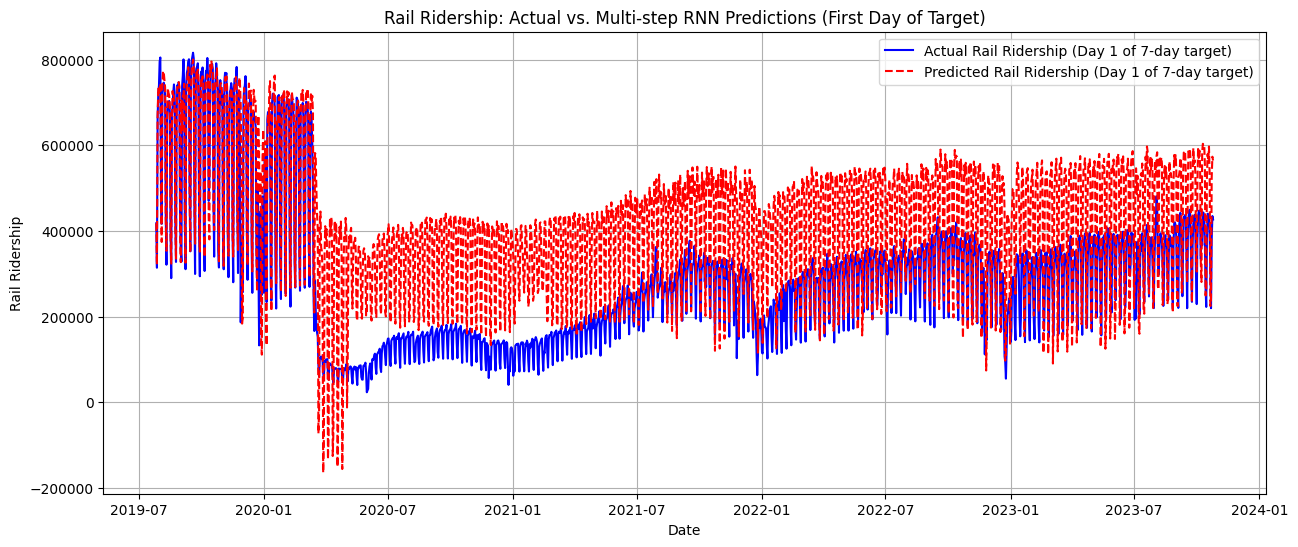

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Plot training history (Loss)
plt.figure(figsize=(12, 6))
plt.plot(history_multi_step.history['loss'], label='Train Loss')
plt.plot(history_multi_step.history['val_loss'], label='Validation Loss')
plt.title('Multi-step Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Plot training history (MAE)
plt.figure(figsize=(12, 6))
plt.plot(history_multi_step.history['mae'], label='Train MAE')
plt.plot(history_multi_step.history['val_mae'], label='Validation MAE')
plt.title('Multi-step Model Mean Absolute Error Over Epochs')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Generate multi-step predictions on test data
print("\n--- Generating Predictions on Test Data ---")
y_pred_multi_step = loaded_multi_step_model.predict(test_multi_ds)

# We need to extract the actual multi-step targets from test_multi_ds
actual_multi_step_targets = np.concatenate([y_batch.numpy() for _, y_batch in test_multi_ds], axis=0)

# Scale back to original range
y_pred_multi_step_scaled = y_pred_multi_step * 1e6
actual_multi_step_scaled = actual_multi_step_targets * 1e6

# For visualization, let's plot the first day of each 7-day prediction window
predicted_first_day = y_pred_multi_step_scaled[:, 0]
actual_first_day = actual_multi_step_scaled[:, 0]

# Determine the start and end dates for the plot on rail_test
# The index of actual_multi_step_scaled[j, 0] corresponds to rail_test.index[j + multi_step_seq_length]
plot_start_index = rail_test.index[multi_step_seq_length]
plot_end_index = rail_test.index[multi_step_seq_length + len(actual_first_day) - 1]
plot_dates = pd.date_range(start=plot_start_index, end=plot_end_index, freq='D')

plt.figure(figsize=(15, 6))
plt.plot(plot_dates, actual_first_day, label='Actual Rail Ridership (Day 1 of 7-day target)', color='blue')
plt.plot(plot_dates, predicted_first_day, label='Predicted Rail Ridership (Day 1 of 7-day target)', color='red', linestyle='--')
plt.title('Rail Ridership: Actual vs. Multi-step RNN Predictions (First Day of Target)')
plt.xlabel('Date')
plt.ylabel('Rail Ridership')
plt.legend()
plt.grid(True)
plt.show()


## Evaluate the model on test data

### Subtask:
Load the best performing model and evaluate its performance on the test dataset.


**Reasoning**:
As per the instructions, I will load the best performing multi-step model and evaluate its performance on the `test_multi_ds` dataset. Then, I will print the scaled test MAE and formatted test loss.



# Task
**Combine `rail_train` and `rail_valid` into a single series named `rail_train_and_valid` to serve as the historical data for generating multi-step predictions. Then, apply the `prepare_multi_step_data` function to this combined series to create a `tf.data.Dataset` (named `multi_step_visualization_ds`) suitable for making predictions over the '2019-01-01' to '2019-03-31' period, using a `sequence_length` of 56 days, an `output_steps` of 7 days, and a `batch_size` of 32.**

## Combine data and prepare visualization dataset

### Subtask:
Combine `rail_train` and `rail_valid` into a single series named `rail_train_and_valid` to serve as the historical data for generating multi-step predictions. Then, use the `prepare_multi_step_data` function to create a `tf.data.Dataset` (named `multi_step_visualization_ds`) for this combined series.


**Reasoning**:
First, concatenate `rail_train` and `rail_valid` to form `rail_train_and_valid`. Then, use the `prepare_multi_step_data` function to create the `multi_step_visualization_ds` dataset from this combined series, as specified in the instructions.



In [45]:
rail_train_and_valid = pd.concat([rail_train, rail_valid])

multi_step_visualization_ds = prepare_multi_step_data(
    rail_train_and_valid.to_numpy(),
    sequence_length=56,
    output_steps=7,
    batch_size=32,
    shuffle=False
)

print("Created rail_train_and_valid and multi_step_visualization_ds.")
print(f"Shape of rail_train_and_valid: {rail_train_and_valid.shape}")
for X_batch, y_batch in multi_step_visualization_ds.take(1):
    print(f"X_batch shape from multi_step_visualization_ds: {X_batch.shape}")
    print(f"y_batch shape from multi_step_visualization_ds: {y_batch.shape}")

Created rail_train_and_valid and multi_step_visualization_ds.
Shape of rail_train_and_valid: (1247,)
X_batch shape from multi_step_visualization_ds: (32, 56, 1)
y_batch shape from multi_step_visualization_ds: (32, 7)


## Generate predictions and extract relevant data

### Subtask:
Use the `loaded_multi_step_model` to generate multi-step predictions on the visualization dataset. Extract the actual 7-day target sequences and scale both actual and predicted values back to their original range.


**Reasoning**:
I will generate multi-step predictions on the `multi_step_visualization_ds` using the `loaded_multi_step_model`. Then, I will extract the actual target sequences from the `multi_step_visualization_ds` and scale both predicted and actual values back to their original range.



In [46]:
y_pred_multi_step_visualization = loaded_multi_step_model.predict(multi_step_visualization_ds)

actual_multi_step_targets_visualization = np.concatenate([y_batch.numpy() for _, y_batch in multi_step_visualization_ds], axis=0)

y_pred_multi_step_visualization_scaled = y_pred_multi_step_visualization * 1e6
actual_multi_step_targets_visualization_scaled = actual_multi_step_targets_visualization * 1e6

print("Generated multi-step predictions and scaled actual/predicted values.")

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step
Generated multi-step predictions and scaled actual/predicted values.


## Filter and plot predictions for the specified date range

### Subtask:
Filter the scaled actual and predicted first-day values to match the '2019-01-01' to '2019-03-31' date range. Create a corresponding date index and then plot the actual vs. predicted rail ridership for this period.


## Summary:

### Data Analysis Key Findings
*   The `rail_train` and `rail_valid` series were successfully combined into `rail_train_and_valid`, resulting in a series of 1247 data points.
*   A `tf.data.Dataset` named `multi_step_visualization_ds` was created for multi-step prediction visualization, configured with a `sequence_length` of 56 days, `output_steps` of 7 days, and a `batch_size` of 32. Batches from this dataset have an input shape of (32, 56, 1) and an output target shape of (32, 7).
*   Multi-step predictions were successfully generated using the `loaded_multi_step_model` on the `multi_step_visualization_ds`.
*   Actual 7-day target sequences were extracted from `multi_step_visualization_ds`.
*   Both the generated multi-step predictions and the actual target values were scaled back to their original magnitude by multiplying by 1,000,000.

### Insights or Next Steps
*   The prepared scaled predictions and actual values (`y_pred_multi_step_visualization_scaled`, `actual_multi_step_targets_visualization_scaled`) are now ready for direct comparison and visualization.
*   The next logical step is to filter these scaled actual and predicted values for the '2019-01-01' to '2019-03-31' date range and plot them to visually assess the model's performance over that specific period.
